# Introduction
The goal is to make a simple model with all the required functionality. The model is as follows:

$$\hat{y} = a sin(b(x-c)) + d$$
$$a, b, c, d = f(edd-ratio, bh-mass), $$
where $f$ is a polynomial

The approach is to first find the parameters of best fit, and then find the function of best fit that connects these parameters and the edd_ratio and bh_mass.


# Getting the data and imports

In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu" #TODO change when they're done with the GPU
import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd
from tinygp import GaussianProcess, kernels
import jaxopt
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
from scipy.optimize import minimize as ScipyMinimize
import math 


/home/zoe/cosmographi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# copy-pasted from tiny_gp_experiments.ipynb:
passband_group = PassbandGroup.from_preset(
    preset="LSST", filters=['u']
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)
#chekc out https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
#I'll just keep this instead of caskade because I'm only gathering some preliminaruy data, will not have it written in final code
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

edd_ratio = SamplePDF(edd_ratio_pdf)

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)


model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=0.1,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=0,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(501)

n = 100


df = simulate_lightcurves(
    model=model,
    num_samples=n,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio"
    ],       
    rng=rng)

Simulating: 100%|██████████| 100/100 [00:30<00:00,  3.32obj/s]


In [3]:
print(df.head())

   id          ra        dec  nobs            t0    z  bh_mass_lg_mass  \
0   0   98.973156 -16.909687   233  60980.001582  0.1         8.258700   
1   1    1.688189 -27.980668   761  60980.001582  0.1         8.519337   
2   2  267.426810 -46.255936   855  60980.001582  0.1         7.437447   
3   3  187.976032 -46.974324   843  60980.001582  0.1         7.870539   
4   4  225.878831   5.087385   789  60980.001582  0.1         7.924820   

   AGN_0_edd_ratio                                         lightcurve  \
0         0.016917  [{mjd: 61030.071009, filter: 'u', flux: 294958...   
1         0.013766  [{mjd: 60990.133471, filter: 'g', flux: 484234...   
2         0.026351  [{mjd: 61150.42466, filter: 'z', flux: 1332.49...   
3         0.080654  [{mjd: 61072.315227, filter: 'z', flux: 223764...   
4         0.017144  [{mjd: 61105.396204, filter: 'r', flux: 29535....   

                                              params  
0  {'NumpyRandomFunc:integers_2.low': 0, 'NumpyRa...  
1  {'N

# Finding a, b, c, d of best fit

In [4]:


def calculate_prediction(params: tuple|list[float], query_times: list[float]) -> float:
    """
    Calculate the predicted values based on the given parameters and query times.

    Args:
        params (tuple[float]): A tuple containing the parameters (a, b, c, d) for the prediction model.
        query_times (list[float]): A list of query times for which to calculate the prediction.

    Returns:
        float: The predicted value for the given query time.
    """
    a, b, c, d = params
    predictions = []
    for t in query_times:
        predictions.append( a * np.sin(b * (t - c)) + d)
    return predictions

def calculate_loss(params: tuple|list[float], query_times: np.ndarray, true_values: np.ndarray) -> float:
    """
    Calculate the mean squared error loss between the predicted values and true values.

    Args:
        params (tuple[float]): A tuple containing the parameters (a, b, c, d) for the prediction model.
        query_times (np.ndarray): An array of query times for which to calculate predictions.
        true_values (np.ndarray): An array of true values corresponding to the query times.

    Returns:
        float: The mean squared error loss between the predicted values and true values.
    """
    predictions = calculate_prediction(params, query_times)
    loss = np.mean((predictions - true_values) ** 2)
    return loss

def optimize_parameters(times, true_values, init_parms):
    """
    Optimize the parameters of the prediction model to minimize the loss.

    Args:
        times (np.ndarray): An array of query times for which to calculate predictions.
        true_values (np.ndarray): An array of true values corresponding to the query times.

    Returns:
        tuple[float]: The optimized parameters (a, b, c, d) that minimize the loss.
    """
    result = ScipyMinimize(fun=calculate_loss, method="Nelder-Mead", x0=init_parms, args = (times, true_values))
    return result.x


In [5]:
results = [['edd_ratio', 'bh_mass_lg_mass', 'a', 'b', 'c', 'd']]

for _index, row in df.iterrows():
    times = row['lightcurve']["mjd"]
    true_values = row['lightcurve']["flux_perfect"]
    optimized_params = optimize_parameters(times, true_values, (0, 0, 0, 0))
    results.append([row["AGN_0_edd_ratio"], row["bh_mass_lg_mass"]] + list(optimized_params))

results = pd.DataFrame(results[1:], columns=results[0])
print(results.head())

results.to_csv("sin_poly_results.csv", index=False)

   edd_ratio  bh_mass_lg_mass              a         b             c  \
0   0.016917         8.258700 -121219.650395  0.000370   -231.953252   
1   0.013766         8.519337 -296583.942304  0.000227 -39990.053171   
2   0.026351         7.437447    -436.682557  0.000363   -772.373094   
3   0.080654         7.870539 -115434.186669  0.000366  -1182.783229   
4   0.017144         7.924820  -19928.092268  0.000372    -63.986737   

               d  
0  144863.521521  
1  165050.372097  
2    1582.661776  
3  122004.406770  
4    9521.794772  


Text(0.5, 1.0, 'd vs edd_ratio')

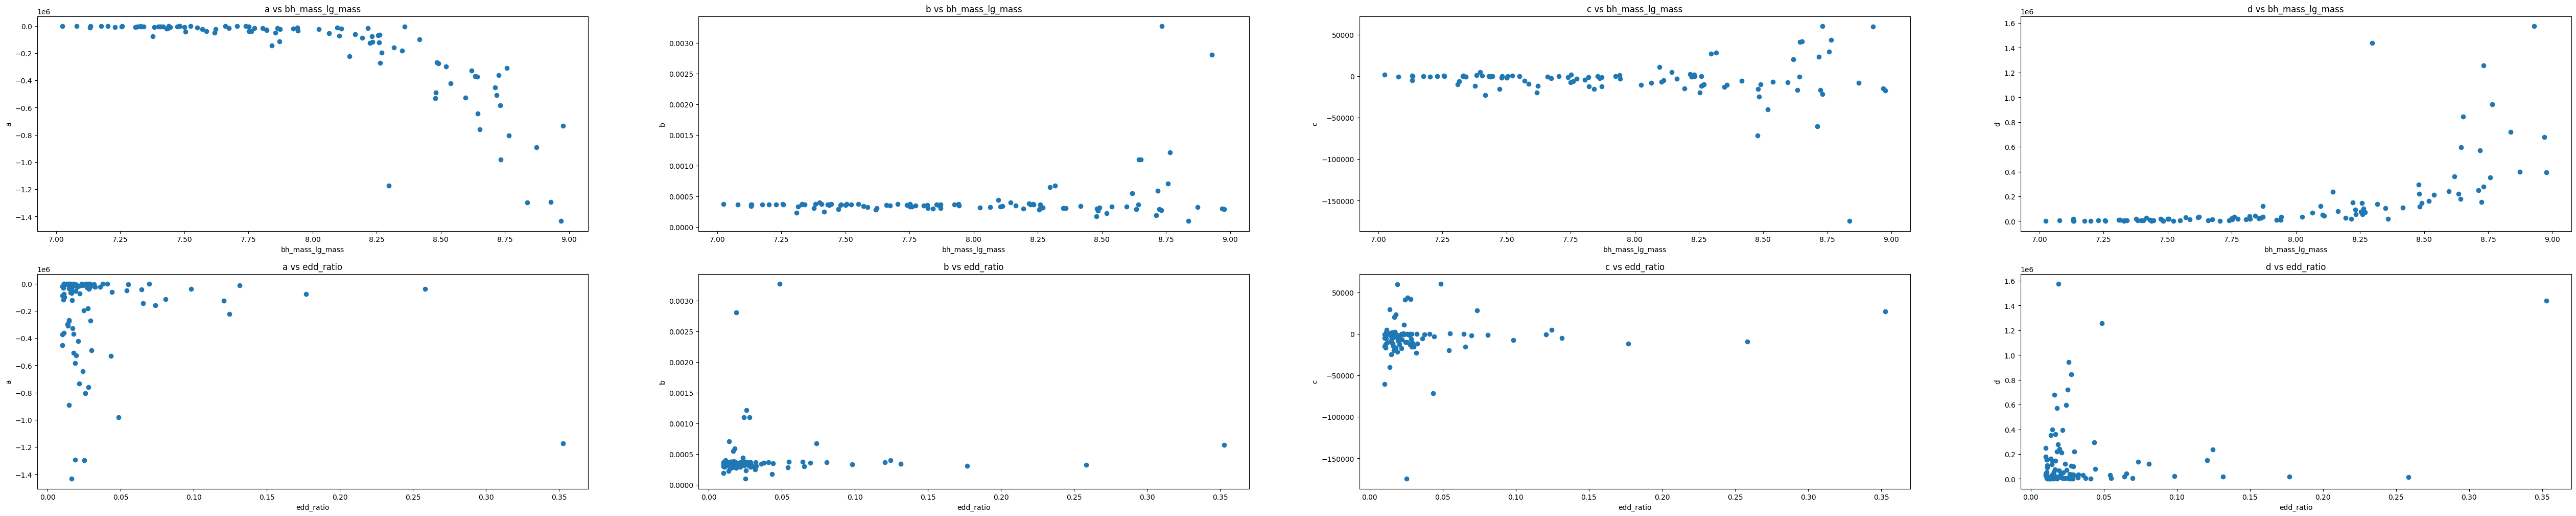

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(64, 12))
axes[0, 0].scatter(results["bh_mass_lg_mass"], results["a"])
axes[0, 0].set_xlabel("bh_mass_lg_mass")
axes[0, 0].set_ylabel("a")
axes[0, 0].set_title("a vs bh_mass_lg_mass")

axes[0, 1].scatter(results["bh_mass_lg_mass"], results["b"])
axes[0, 1].set_xlabel("bh_mass_lg_mass")
axes[0, 1].set_ylabel("b")
axes[0, 1].set_title("b vs bh_mass_lg_mass")

axes[0, 2].scatter(results["bh_mass_lg_mass"], results["c"])
axes[0, 2].set_xlabel("bh_mass_lg_mass")
axes[0, 2].set_ylabel("c")
axes[0, 2].set_title("c vs bh_mass_lg_mass")

axes[0, 3].scatter(results["bh_mass_lg_mass"], results["d"])
axes[0, 3].set_xlabel("bh_mass_lg_mass")
axes[0, 3].set_ylabel("d")
axes[0, 3].set_title("d vs bh_mass_lg_mass")

axes[1, 0].scatter(results["edd_ratio"], results["a"])
axes[1, 0].set_xlabel("edd_ratio")
axes[1, 0].set_ylabel("a")
axes[1, 0].set_title("a vs edd_ratio")  

axes[1, 1].scatter(results["edd_ratio"], results["b"])
axes[1, 1].set_xlabel("edd_ratio")  
axes[1, 1].set_ylabel("b")
axes[1, 1].set_title("b vs edd_ratio")  

axes[1, 2].scatter(results["edd_ratio"], results["c"])
axes[1, 2].set_xlabel("edd_ratio")      
axes[1, 2].set_ylabel("c")
axes[1, 2].set_title("c vs edd_ratio")

axes[1, 3].scatter(results["edd_ratio"], results["d"])
axes[1, 3].set_xlabel("edd_ratio")      
axes[1, 3].set_ylabel("d")
axes[1, 3].set_title("d vs edd_ratio")

In [7]:
def calculate_linear_prediction(params: tuple|list[float], bh_mass_lg_mass: float, edd_ratio: float) -> float:
    """
    Calculate the predicted value based on a linear combination of bh_mass_lg_mass and edd_ratio.
    Args:
        params (tuple[float]): A tuple containing the parameters (m, n, p) for the linear model.
        bh_mass_lg_mass (float): The logarithm of the black hole mass.
        edd_ratio (float): The Eddington ratio.
    Returns:
        float: The predicted value based on the linear model.
    """
    m, n, p = params
    prediction = m * bh_mass_lg_mass + n * edd_ratio + p
    return prediction

def calculate_linear_loss(params: tuple|list[float], bh_mass_lg_mass: np.ndarray, edd_ratio: np.ndarray, true_values: np.ndarray) -> float:
    """
    Calculate the mean squared error loss between the predicted values from the linear model and true values.
    Args:
        params (tuple[float]): A tuple containing the parameters (m, n, p) for the linear model.
        bh_mass_lg_mass (np.ndarray): An array of logarithm of black hole masses.
        edd_ratio (np.ndarray): An array of Eddington ratios.
        true_values (np.ndarray): An array of true values corresponding to the query times.
    Returns:
        float: The mean squared error loss between the predicted values and true values.
    """
    predictions = calculate_linear_prediction(params, bh_mass_lg_mass, edd_ratio)
    loss = np.mean((predictions - true_values) ** 2)
    return loss


def optimize_linear_letter(true_p_val, bh_mass, edd_ratio, init_parms):
    """
    Optimize the parameters to fit a linear model to one of the "first-level parameters", such that, if k is the letter param:
    k = m * bh_mass_lg_mass + n * edd_ratio + p:

    Args:
        true_p_val (np.ndarray): An array of true values for the parameter to be optimized.
        bh_mass (np.ndarray): An array of black hole masses.

    Returns:
        tuple[float]: The optimized parameters (m, n, p)
    """
    
    best_params = ScipyMinimize(fun=calculate_linear_loss, method="Nelder-Mead", x0=init_parms, args = (bh_mass, edd_ratio, true_p_val))
    return best_params.x


In [11]:
a_coef = optimize_linear_letter(results["a"].values, results["bh_mass_lg_mass"].values, results["edd_ratio"].values, (0, 0, 0))
b_coef = optimize_linear_letter(results["b"].values, results["bh_mass_lg_mass"].values, results["edd_ratio"].values, (0, 0, 0))
c_coef = optimize_linear_letter(results["c"].values, results["bh_mass_lg_mass"].values, results["edd_ratio"].values, (0, 0, 0))
d_coef = optimize_linear_letter(results["d"].values, results["bh_mass_lg_mass"].values, results["edd_ratio"].values, (0, 0, 0))

print ("a_coef:", a_coef.round(0))
print ("b_coef:", b_coef.round(0))
print ("c_coef:", c_coef.round(0))       
print ("d_coef:", d_coef.round(0))

a_coef: [-452437. -701078. 3432715.]
b_coef: [0. 0. 0.]
c_coef: [   88. 32186. -6456.]
d_coef: [  303617.  2608280. -2351906.]


In [ ]:
from cosmographi.source import AGN
from cosmographi.cosmology import Cosmology
agn = AGN(Cosmology, 8, 0.05)
luminosity_density = AGN.luminosity_density(z=0.1, )